# 🚲 Análisis Exploratorio de Datos — London Bike Sharing

**Dataset:** `london_merged.csv`  
**Fuente:** Kaggle — London Bike Sharing Dataset  
**Objetivo:** Analizar el comportamiento del sistema de bicicletas compartidas de Londres, limpiar el dataset, explorar relaciones entre variables y evaluar técnicas de reducción de dimensionalidad (PCA).

---

## Contenido
1. Carga de librerías y datos
2. Descripción de la estructura del dataset
3. Análisis exploratorio (EDA) — estadísticas y gráficos
4. Detección y tratamiento de datos faltantes y errores
5. Justificación de decisiones de limpieza
6. Evaluación de PCA
7. Conclusiones sobre la calidad del dataset

---
## 1. Carga de Librerías y Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# --- Carga del dataset ---
df_raw = pd.read_csv('archive/london_merged.csv')
df = df_raw.copy()
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado: 17,414 filas x 10 columnas


,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


---
## 2. Descripción de la Estructura del Dataset

### 2.1 Variables y sus tipos

| Variable | Tipo Original | Descripción |
|---|---|---|
| `timestamp` | object (string) | Fecha y hora del registro (cada hora) |
| `cnt` | int64 | Cantidad de bicicletas alquiladas en esa hora (**variable objetivo**) |
| `t1` | float64 | Temperatura real (°C) |
| `t2` | float64 | Temperatura aparente / sensación térmica (°C) |
| `hum` | float64 | Humedad relativa (%) |
| `wind_speed` | float64 | Velocidad del viento (km/h) |
| `weather_code` | float64 | Código de condición climática (categórica ordinal) |
| `is_holiday` | float64 | 1 = día feriado, 0 = día normal |
| `is_weekend` | float64 | 1 = fin de semana, 0 = día de semana |
| `season` | float64 | Estación del año: 0=primavera, 1=verano, 2=otoño, 3=invierno |

In [2]:
# Resumen de tipos y valores únicos
resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores unicos': df.nunique(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().mean() * 100).round(2),
    'Ejemplo': [str(df[c].dropna().iloc[0]) for c in df.columns]
})
print(f'Observaciones totales: {df.shape[0]:,}')
print(f'Variables: {df.shape[1]}')
resumen

Observaciones totales: 17,414
Variables: 10


,Tipo,Valores unicos,Nulos,% Nulos,Ejemplo
timestamp,object,17414,0,0.0,2015-01-04 00:00:00
cnt,int64,3781,0,0.0,182
t1,float64,73,0,0.0,3.0
t2,float64,82,0,0.0,2.0
hum,float64,143,0,0.0,93.0
wind_speed,float64,103,0,0.0,6.0
weather_code,float64,7,0,0.0,3.0
is_holiday,float64,2,0,0.0,0.0
is_weekend,float64,2,0,0.0,1.0
season,float64,4,0,0.0,3.0


In [3]:
# Convertir timestamp a datetime y extraer componentes temporales
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year']  = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['hour']  = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=lunes

print('Rango temporal:')
print(f"  Inicio : {df['timestamp'].min()}")
print(f"  Fin    : {df['timestamp'].max()}")
print(f"  Anios  : {sorted(df['year'].unique())}")

Rango temporal:
  Inicio : 2015-01-04 00:00:00
  Fin    : 2017-01-03 23:00:00
  Anios  : [np.int32(2015), np.int32(2016), np.int32(2017)]


In [4]:
# Estadísticas descriptivas completas (solo numéricas para evitar errores con datetime)
df.select_dtypes(include='number').describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','min','max'])

,count,mean,std,min,25%,50%,75%,max
cnt,17414.000000,1143.101642,1085.108068,0.000000,257.000000,844.000000,1671.750000,7860.000000
t1,17414.000000,12.468091,5.571818,-1.500000,8.000000,12.500000,16.000000,34.000000
t2,17414.000000,11.520836,6.615145,-6.000000,6.000000,12.500000,16.000000,34.000000
hum,17414.000000,72.324954,14.313186,20.500000,63.000000,74.500000,83.000000,100.000000
wind_speed,17414.000000,15.913063,7.894570,0.000000,10.000000,15.000000,20.500000,56.500000
weather_code,17414.000000,2.722752,2.341163,1.000000,1.000000,2.000000,3.000000,26.000000
is_holiday,17414.000000,0.022051,0.146854,0.000000,0.000000,0.000000,0.000000,1.000000
is_weekend,17414.000000,0.285403,0.451619,0.000000,0.000000,0.000000,1.000000,1.000000
season,17414.000000,1.492075,1.118911,0.000000,0.000000,1.000000,2.000000,3.000000
year,17414.000000,2015.507810,0.508157,2015.000000,2015.000000,2016.000000,2016.000000,2017.000000


---
## 3. Análisis Exploratorio (EDA)

### 3.1 Distribución de la variable objetivo `cnt`

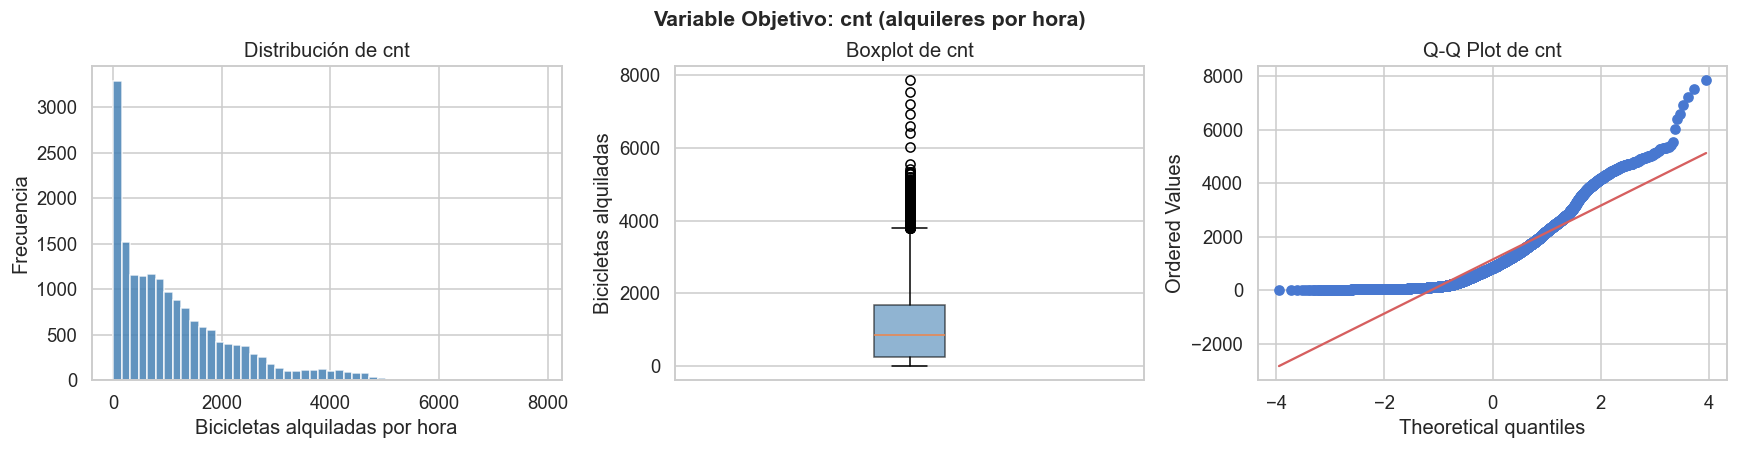

Asimetría (skewness): 1.326
Curtosis (kurtosis) : 1.545
Media               : 1143.1
Mediana             : 844.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['cnt'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de cnt')
axes[0].set_xlabel('Bicicletas alquiladas por hora')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['cnt'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de cnt')
axes[1].set_ylabel('Bicicletas alquiladas')
axes[1].set_xticks([])

stats.probplot(df['cnt'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot de cnt')

plt.tight_layout()
plt.suptitle('Variable Objetivo: cnt (alquileres por hora)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print(f"Asimetría (skewness): {df['cnt'].skew():.3f}")
print(f"Curtosis (kurtosis) : {df['cnt'].kurtosis():.3f}")
print(f"Media               : {df['cnt'].mean():.1f}")
print(f"Mediana             : {df['cnt'].median():.1f}")

### 3.2 Distribución de variables numéricas continuas

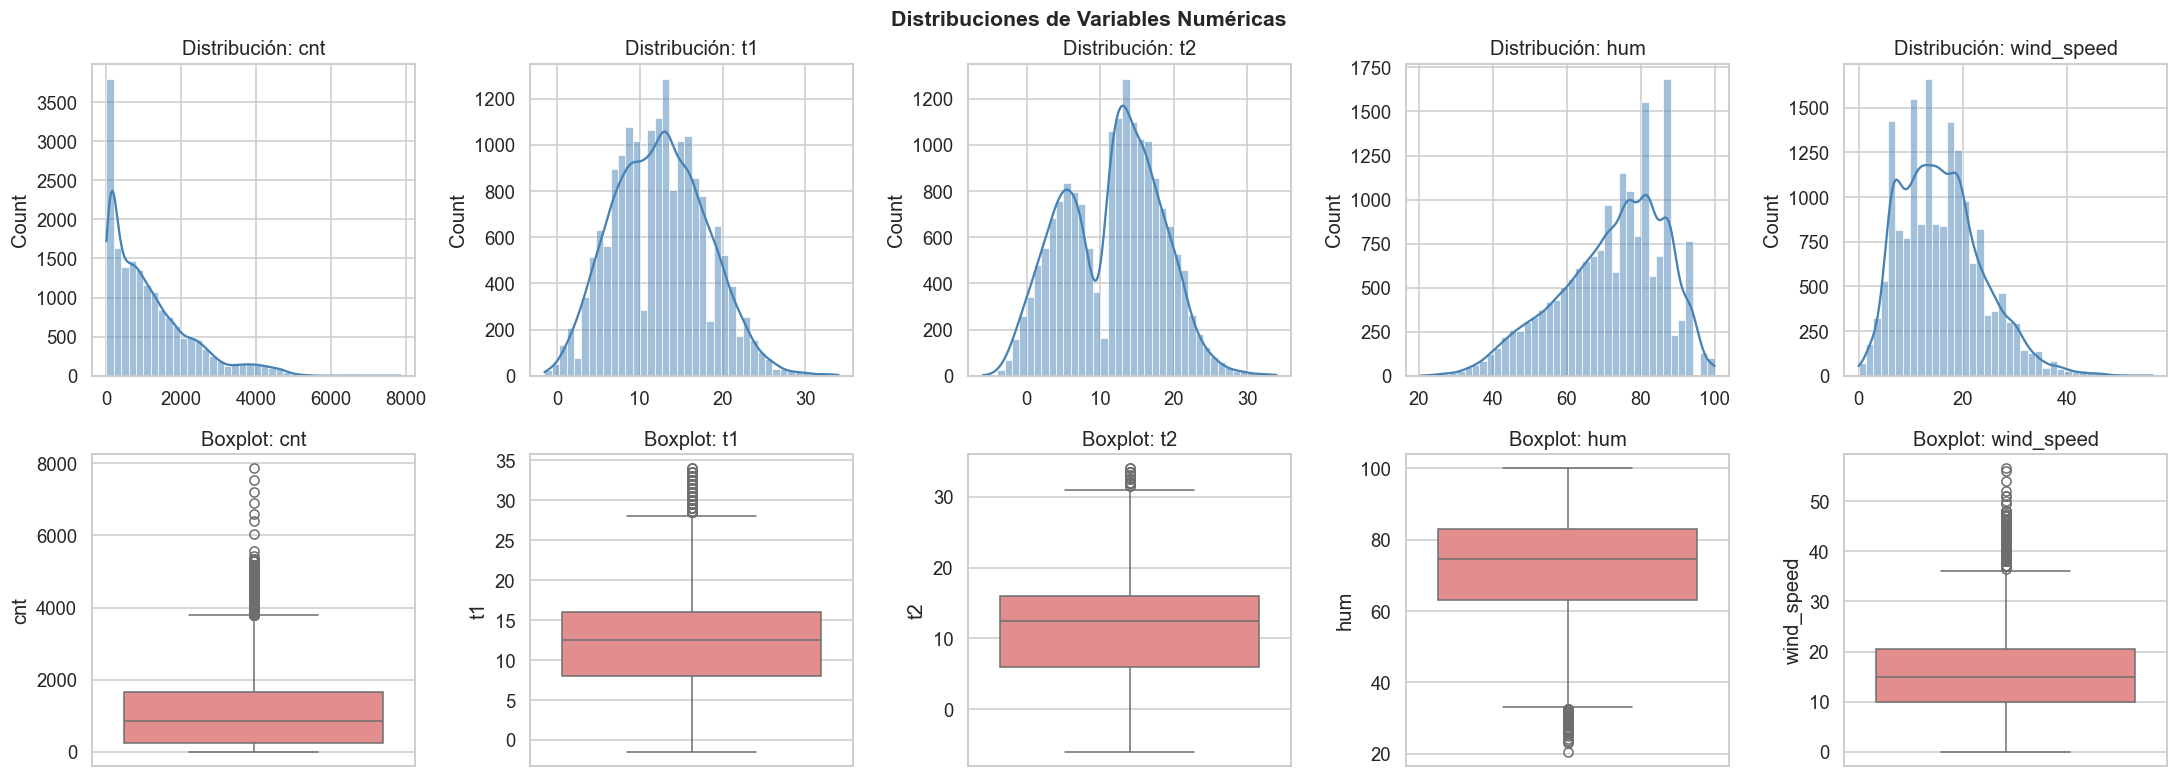

In [6]:
num_vars = ['cnt', 't1', 't2', 'hum', 'wind_speed']
fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for i, var in enumerate(num_vars):
    sns.histplot(df[var], ax=axes[0, i], kde=True, color='steelblue', bins=40)
    axes[0, i].set_title(f'Distribución: {var}')
    axes[0, i].set_xlabel('')
    sns.boxplot(y=df[var], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'Boxplot: {var}')

plt.tight_layout()
plt.suptitle('Distribuciones de Variables Numéricas', y=1.01, fontsize=14, fontweight='bold')
plt.show()

### 3.3 Variables categóricas (codificadas como numéricas)

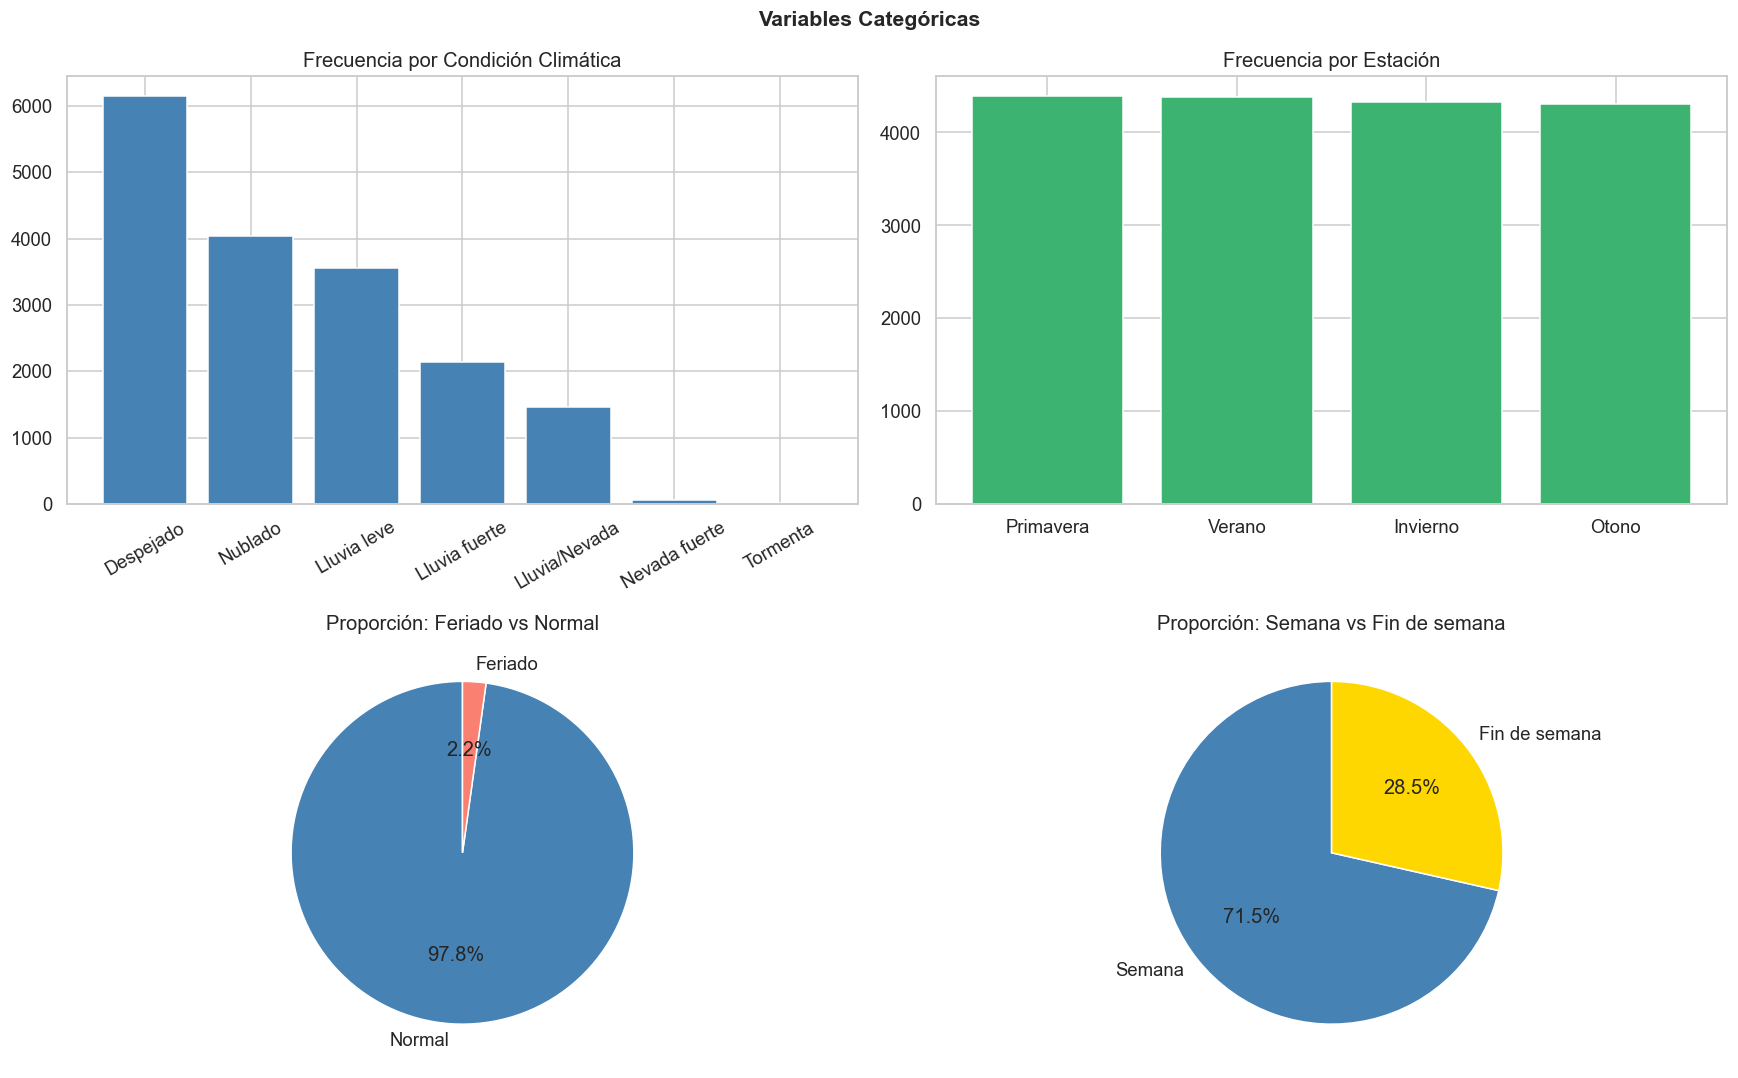

In [7]:
weather_map = {
    1: 'Despejado', 2: 'Nublado', 3: 'Lluvia leve',
    4: 'Lluvia/Nevada', 7: 'Lluvia fuerte', 10: 'Tormenta', 26: 'Nevada fuerte'
}
season_map = {0: 'Primavera', 1: 'Verano', 2: 'Otono', 3: 'Invierno'}

df['weather_label'] = df['weather_code'].map(weather_map).fillna('Otro')
df['season_label']  = df['season'].map(season_map)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

wc_counts = df['weather_label'].value_counts()
axes[0,0].bar(wc_counts.index, wc_counts.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Frecuencia por Condición Climática')
axes[0,0].tick_params(axis='x', rotation=30)

s_counts = df['season_label'].value_counts()
axes[0,1].bar(s_counts.index, s_counts.values, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Frecuencia por Estación')

hol = df['is_holiday'].value_counts()
axes[1,0].pie(hol.values, labels=['Normal','Feriado'], autopct='%1.1f%%',
              colors=['steelblue','salmon'], startangle=90)
axes[1,0].set_title('Proporción: Feriado vs Normal')

wkd = df['is_weekend'].value_counts()
axes[1,1].pie(wkd.values, labels=['Semana','Fin de semana'], autopct='%1.1f%%',
              colors=['steelblue','gold'], startangle=90)
axes[1,1].set_title('Proporción: Semana vs Fin de semana')

plt.suptitle('Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Análisis temporal

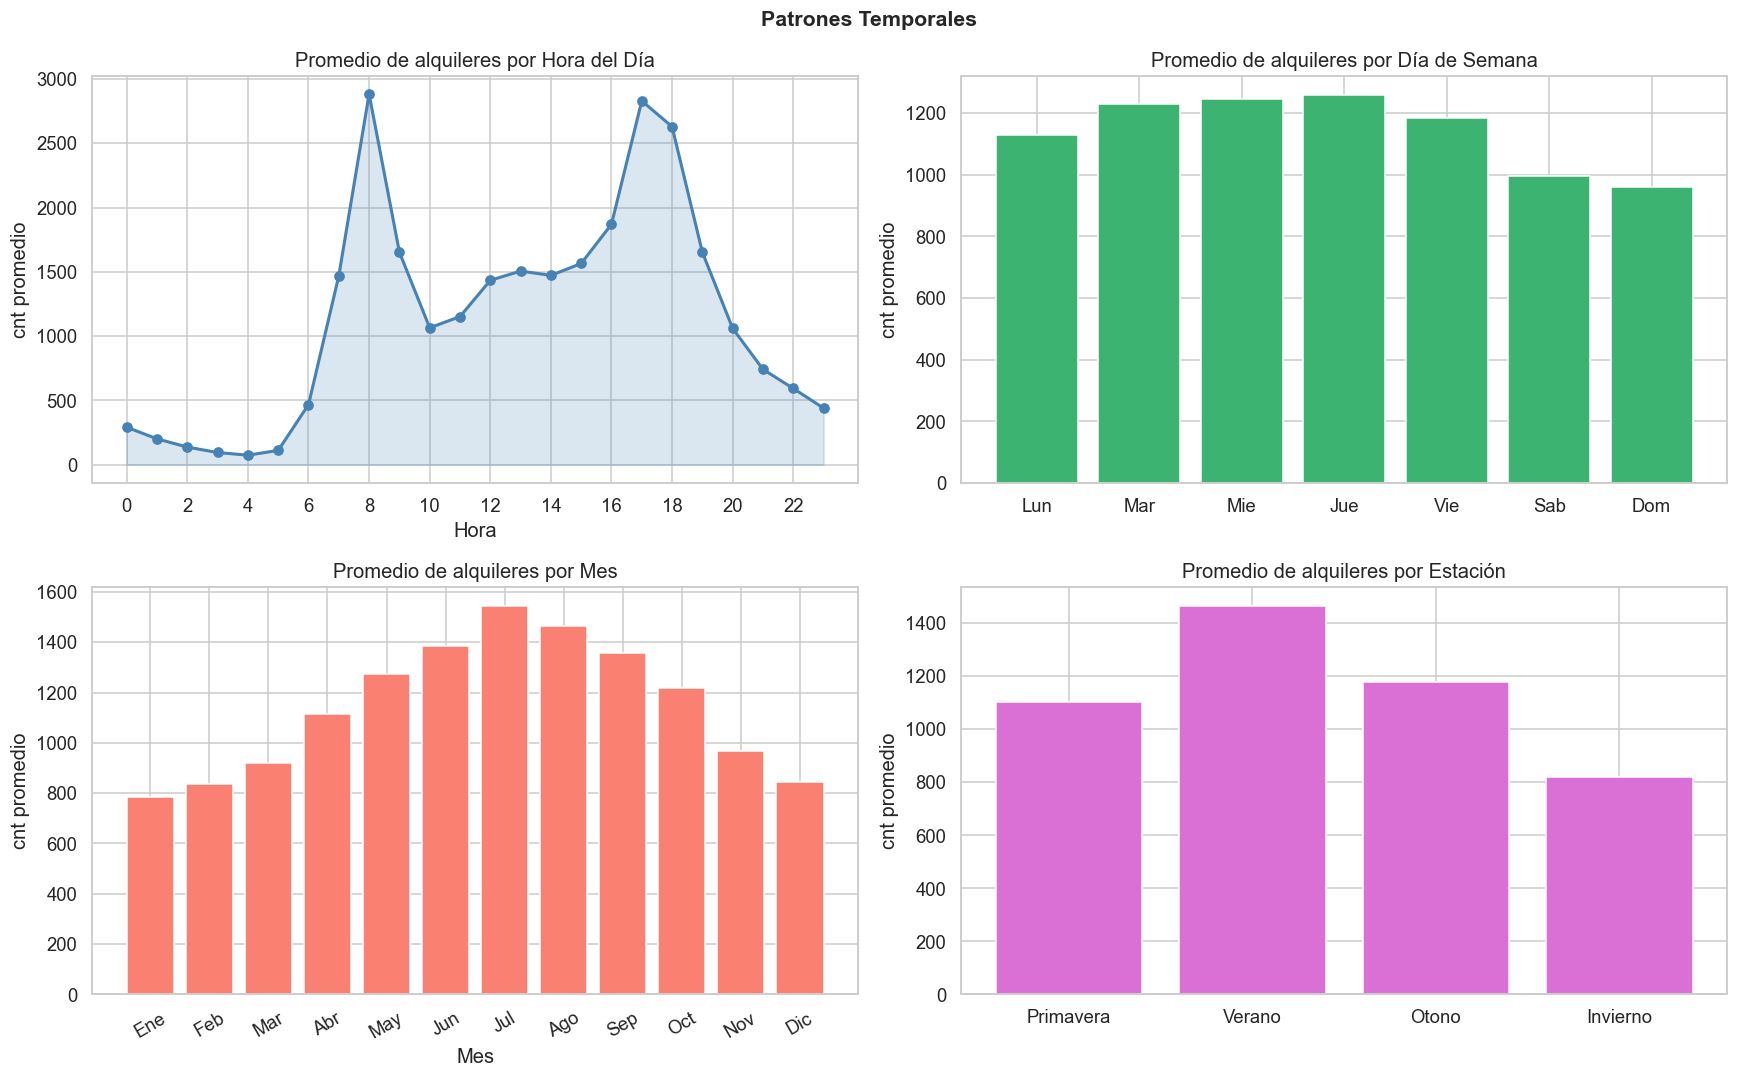

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

hourly = df.groupby('hour')['cnt'].mean()
axes[0,0].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[0,0].fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
axes[0,0].set_title('Promedio de alquileres por Hora del Día')
axes[0,0].set_xlabel('Hora')
axes[0,0].set_ylabel('cnt promedio')
axes[0,0].set_xticks(range(0, 24, 2))

day_names = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
weekly = df.groupby('day_of_week')['cnt'].mean()
axes[0,1].bar(day_names, weekly.values, color='mediumseagreen', edgecolor='white')
axes[0,1].set_title('Promedio de alquileres por Día de Semana')
axes[0,1].set_ylabel('cnt promedio')

monthly = df.groupby('month')['cnt'].mean()
axes[1,0].bar(range(1,13), monthly.values, color='salmon', edgecolor='white')
axes[1,0].set_title('Promedio de alquileres por Mes')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('cnt promedio')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=30)

seasonal = df.groupby('season_label')['cnt'].mean().reindex(['Primavera','Verano','Otono','Invierno'])
axes[1,1].bar(seasonal.index, seasonal.values, color='orchid', edgecolor='white')
axes[1,1].set_title('Promedio de alquileres por Estación')
axes[1,1].set_ylabel('cnt promedio')

plt.suptitle('Patrones Temporales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

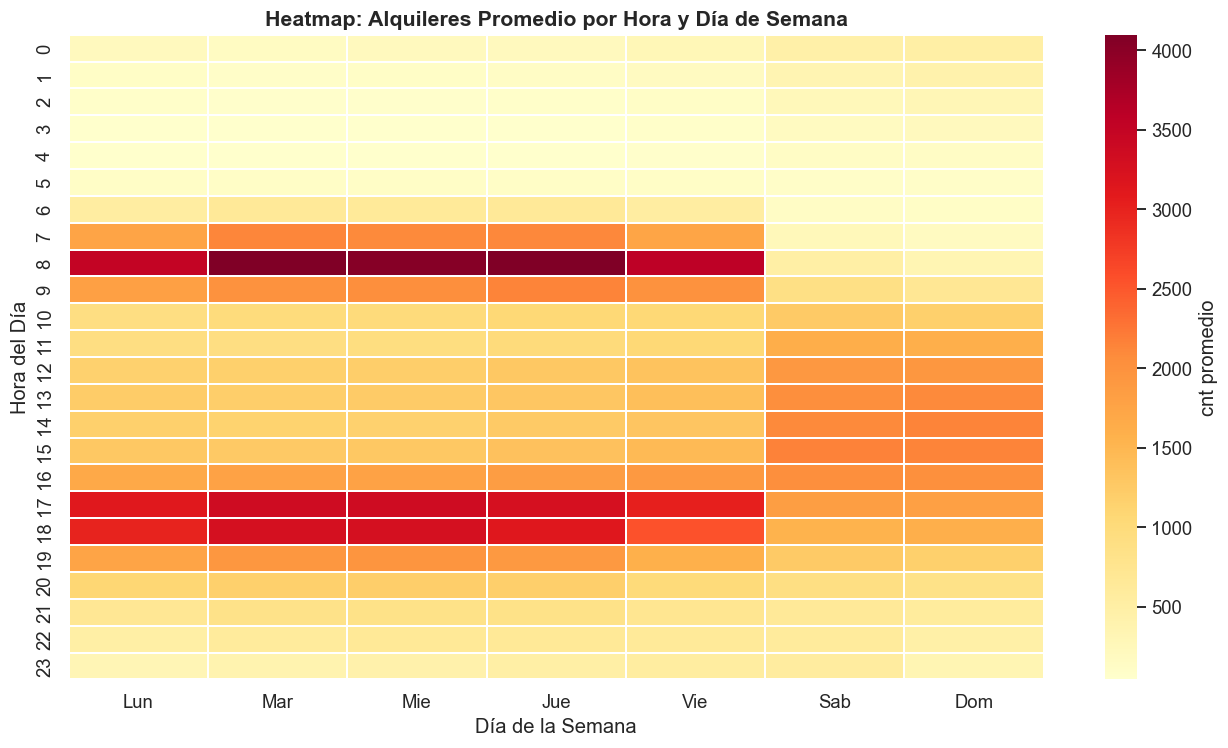

In [9]:
pivot = df.pivot_table(values='cnt', index='hour', columns='day_of_week', aggfunc='mean')
pivot.columns = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.3, cbar_kws={'label': 'cnt promedio'})
plt.title('Heatmap: Alquileres Promedio por Hora y Día de Semana', fontsize=14, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Hora del Día')
plt.tight_layout()
plt.show()

### 3.5 Relaciones entre variables

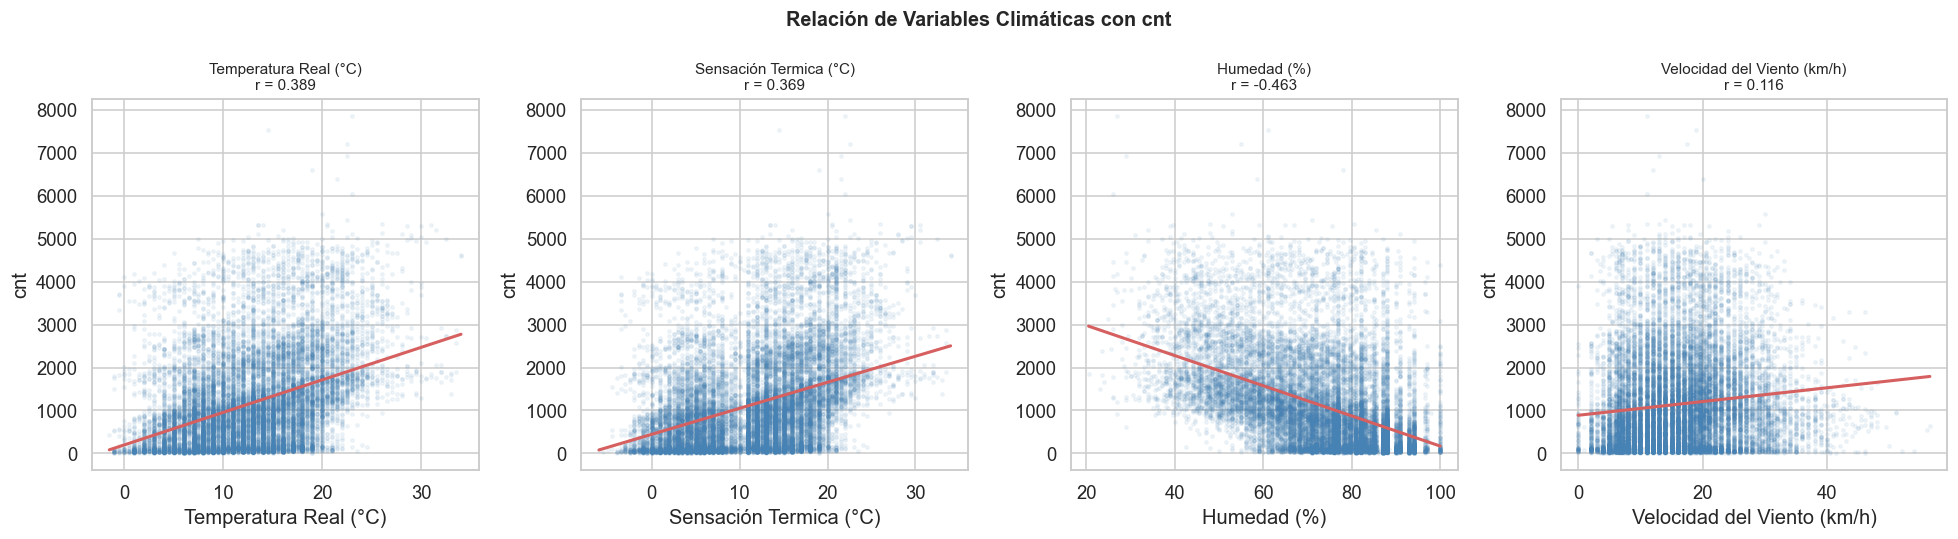

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

scatter_vars = [('t1','Temperatura Real (°C)'), ('t2','Sensación Termica (°C)'),
                ('hum','Humedad (%)'), ('wind_speed','Velocidad del Viento (km/h)')]

for i, (var, label) in enumerate(scatter_vars):
    axes[i].scatter(df[var], df['cnt'], alpha=0.07, s=5, color='steelblue')
    z = np.polyfit(df[var].dropna(), df.loc[df[var].notna(), 'cnt'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[var].min(), df[var].max(), 100)
    axes[i].plot(xs, p(xs), 'r-', linewidth=2)
    corr = df[var].corr(df['cnt'])
    axes[i].set_title(f'{label}\nr = {corr:.3f}', fontsize=10)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('cnt')

plt.suptitle('Relación de Variables Climáticas con cnt', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

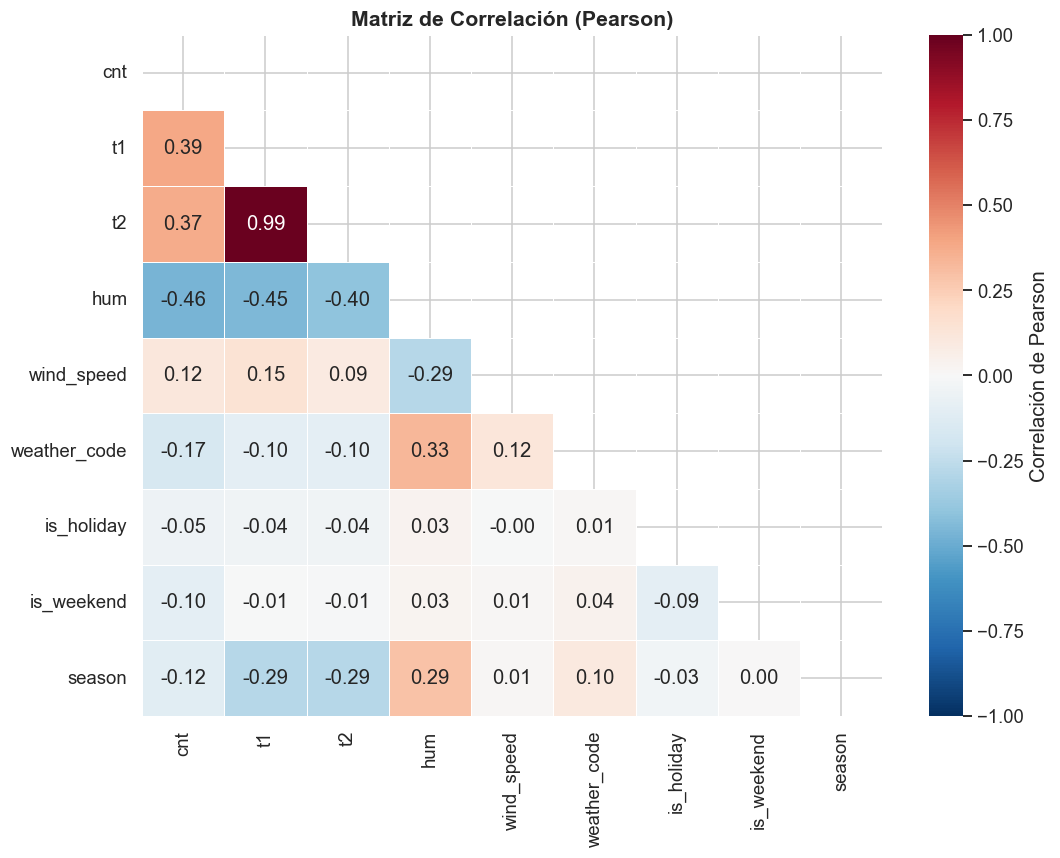


Correlaciones con cnt (ordenadas):
t1              0.388798
t2              0.369035
wind_speed      0.116295
is_holiday     -0.051698
is_weekend     -0.096499
season         -0.116180
weather_code   -0.166633
hum            -0.462901


In [11]:
num_cols = ['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de Correlación (Pearson)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con cnt (ordenadas):')
print(corr_matrix['cnt'].drop('cnt').sort_values(ascending=False).to_string())

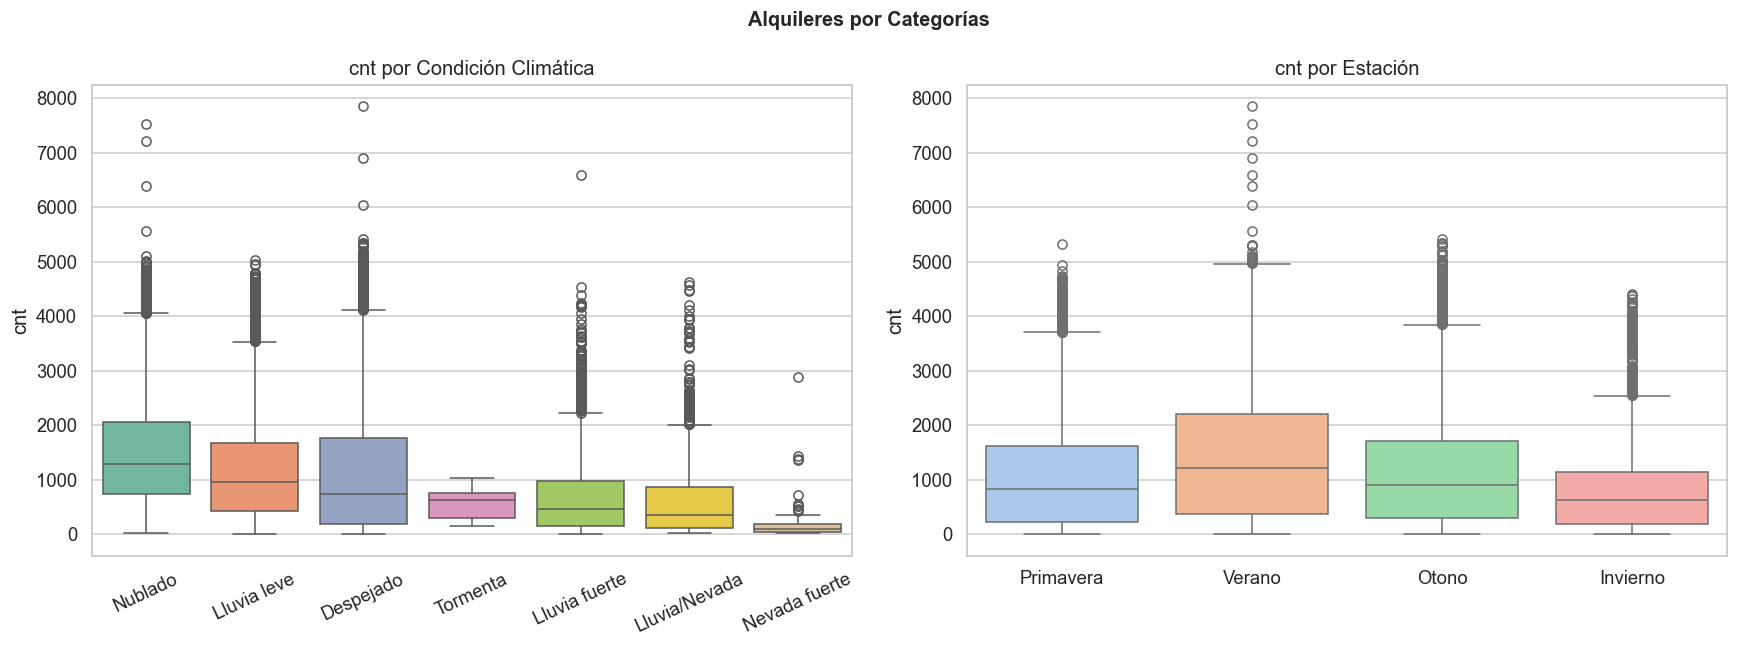

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df[df['weather_label'] != 'Otro'].copy()
order_weather = df_plot.groupby('weather_label')['cnt'].median().sort_values(ascending=False).index
sns.boxplot(data=df_plot, x='weather_label', y='cnt', order=order_weather, palette='Set2', ax=axes[0])
axes[0].set_title('cnt por Condición Climática')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_xlabel('')

order_season = ['Primavera','Verano','Otono','Invierno']
sns.boxplot(data=df, x='season_label', y='cnt', order=order_season, palette='pastel', ax=axes[1])
axes[1].set_title('cnt por Estación')
axes[1].set_xlabel('')

plt.suptitle('Alquileres por Categorías', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Detección y Tratamiento de Datos Faltantes y Errores

In [13]:
print('=== VALORES NULOS ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'No hay valores nulos en ninguna columna.')

n_dup = df.duplicated().sum()
print(f'\nFilas duplicadas: {n_dup}')
n_dup_ts = df.duplicated(subset=['timestamp']).sum()
print(f'Timestamps duplicados: {n_dup_ts}')

=== VALORES NULOS ===
No hay valores nulos en ninguna columna.

Filas duplicadas: 0
Timestamps duplicados: 0


In [14]:
print('=== DETECCIÓN DE OUTLIERS (Método IQR) ===')
iqr_cols = ['cnt', 't1', 't2', 'hum', 'wind_speed']

for col in iqr_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:12s} | [{lower:7.2f}, {upper:7.2f}] | Outliers: {n_out:4d} ({n_out/len(df)*100:.2f}%)')

=== DETECCIÓN DE OUTLIERS (Método IQR) ===
cnt          | [-1865.12, 3793.88] | Outliers:  675 (3.88%)
t1           | [  -4.00,   28.00] | Outliers:   64 (0.37%)
t2           | [  -9.00,   31.00] | Outliers:   19 (0.11%)
hum          | [  33.00,  113.00] | Outliers:   71 (0.41%)
wind_speed   | [  -5.75,   36.25] | Outliers:  236 (1.36%)


In [15]:
print('=== VERIFICACIÓN DE RANGOS DOMAIN-VALID ===')
checks = {
    'cnt < 0':            (df['cnt'] < 0).sum(),
    'hum < 0':            (df['hum'] < 0).sum(),
    'hum > 100':          (df['hum'] > 100).sum(),
    'wind_speed < 0':     (df['wind_speed'] < 0).sum(),
    't1 < -20 o > 50':    ((df['t1'] < -20) | (df['t1'] > 50)).sum(),
    'weather_code inv.':  (~df['weather_code'].isin([1,2,3,4,7,10,26])).sum(),
    'is_holiday inv.':    (~df['is_holiday'].isin([0,1])).sum(),
    'is_weekend inv.':    (~df['is_weekend'].isin([0,1])).sum(),
    'season inv.':        (~df['season'].isin([0,1,2,3])).sum(),
}

for check, count in checks.items():
    status = 'OK' if count == 0 else f'PROBLEMA: {count} registros'
    print(f'{check:25s}: {status}')

=== VERIFICACIÓN DE RANGOS DOMAIN-VALID ===
cnt < 0                  : OK
hum < 0                  : OK
hum > 100                : OK
wind_speed < 0           : OK
t1 < -20 o > 50          : OK
weather_code inv.        : OK
is_holiday inv.          : OK
is_weekend inv.          : OK
season inv.              : OK


In [16]:
df_sorted = df.sort_values('timestamp').reset_index(drop=True)
time_diffs = df_sorted['timestamp'].diff().dropna()
expected_gap = pd.Timedelta(hours=1)
gaps = time_diffs[time_diffs != expected_gap]
print(f'Horas esperadas en el rango: {int((df["timestamp"].max() - df["timestamp"].min()).total_seconds()/3600) + 1}')
print(f'Filas en el dataset        : {len(df)}')
print(f'Gaps temporales irregulares: {len(gaps)}')
if len(gaps) > 0:
    for idx in list(gaps.index)[:5]:
        print(f'  {df_sorted.loc[idx-1,"timestamp"]} -> {df_sorted.loc[idx,"timestamp"]} ({time_diffs.loc[idx]})')

Horas esperadas en el rango: 17544
Filas en el dataset        : 17414
Gaps temporales irregulares: 30
  2015-01-07 18:00:00 -> 2015-01-07 20:00:00 (0 days 02:00:00)
  2015-02-10 20:00:00 -> 2015-02-10 22:00:00 (0 days 02:00:00)
  2015-03-29 01:00:00 -> 2015-03-29 03:00:00 (0 days 02:00:00)
  2015-03-31 01:00:00 -> 2015-03-31 06:00:00 (0 days 05:00:00)
  2015-04-04 09:00:00 -> 2015-04-04 11:00:00 (0 days 02:00:00)


---
## 5. Justificación de Decisiones de Limpieza

In [17]:
df_clean = df.copy()
log_limpieza = []

# Decisión 1: timestamp ya convertido
assert df_clean['timestamp'].dtype == 'datetime64[ns]'
log_limpieza.append(('timestamp -> datetime', 'Conversión', 'Permite análisis temporal; sin pérdida de datos'))

# Decisión 2: Corrección de tipos categóricos
cat_cols = ['weather_code', 'is_holiday', 'is_weekend', 'season']
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(int)
log_limpieza.append(('weather_code, is_holiday, is_weekend, season -> int',
                     'Corrección de tipo',
                     'Variables categóricas no deben tratarse como float continua'))

# Decisión 3: No eliminar outliers de cnt
Q1_cnt, Q3_cnt = df_clean['cnt'].quantile([0.25, 0.75])
IQR_cnt = Q3_cnt - Q1_cnt
n_out_cnt = ((df_clean['cnt'] < Q1_cnt - 1.5*IQR_cnt) | (df_clean['cnt'] > Q3_cnt + 1.5*IQR_cnt)).sum()
log_limpieza.append((f'Outliers de cnt: {n_out_cnt} registros',
                     'Conservados',
                     'Corresponden a horas pico legítimas; eliminarlos introduce sesgo'))

# Decisión 4: hum=100 es válido
n_hum_100 = (df_clean['hum'] == 100).sum()
log_limpieza.append((f'hum=100 en {n_hum_100} registros',
                     'Conservados',
                     'Valor físicamente válido (saturación)'))

# Decisión 5: Feature engineering
df_clean['temp_diff'] = df_clean['t1'] - df_clean['t2']
log_limpieza.append(('temp_diff = t1 - t2',
                     'Feature engineering',
                     'Captura el efecto del viento/humedad en la sensación térmica'))

log_df = pd.DataFrame(log_limpieza, columns=['Elemento', 'Decisión', 'Justificación'])
print(f'Dataset limpio: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
print(f'Filas eliminadas: {len(df) - len(df_clean)}')
print()
log_df

Dataset limpio: 17,414 filas x 17 columnas
Filas eliminadas: 0



,Elemento,Decisión,Justificación
0,timestamp -> datetime,Conversión,Permite análisis temporal; sin pérdida de datos
1,"weather_code, is_holiday, is_weekend, season -...",Corrección de tipo,Variables categóricas no deben tratarse como f...
2,Outliers de cnt: 675 registros,Conservados,Corresponden a horas pico legítimas; eliminarl...
3,hum=100 en 100 registros,Conservados,Valor físicamente válido (saturación)
4,temp_diff = t1 - t2,Feature engineering,Captura el efecto del viento/humedad en la sen...


---
## 6. Evaluación de PCA (Análisis de Componentes Principales)

In [18]:
pca_cols = ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'month']
X = df_clean[pca_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Variables incluidas en PCA:', pca_cols)
print(f'Dimensiones: {X_scaled.shape}')

Variables incluidas en PCA: ['t1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season', 'hour', 'month']
Dimensiones: (17414, 10)


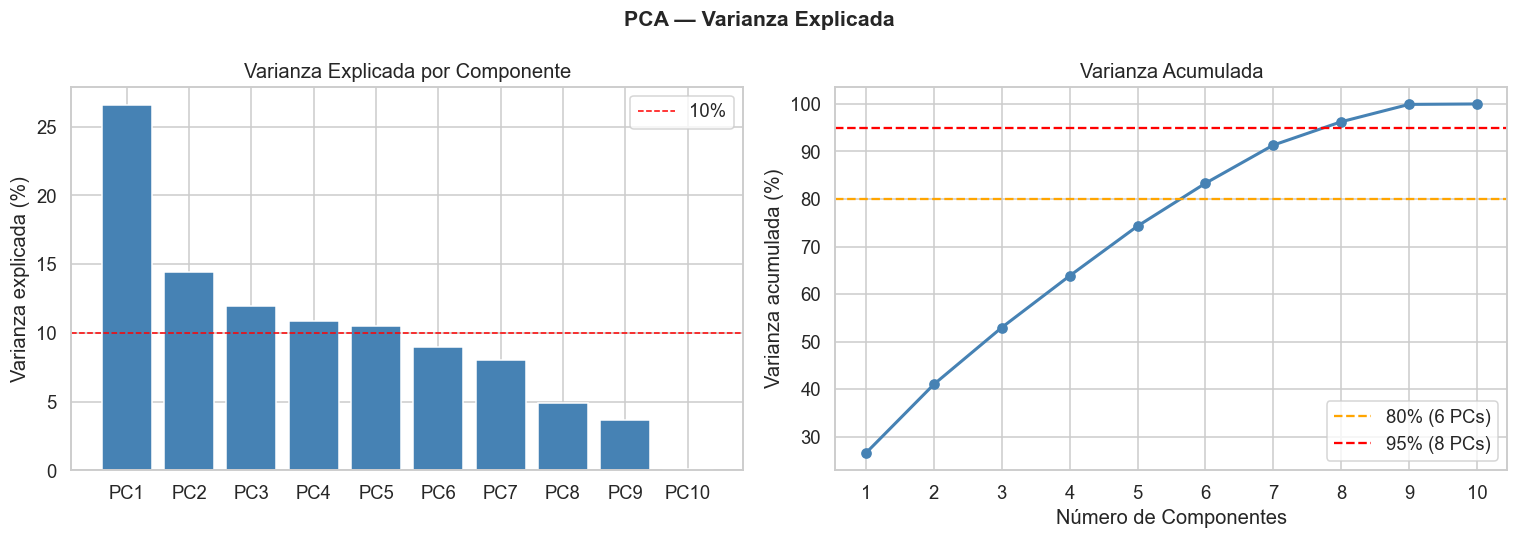

Componentes para 80% varianza: 6
Componentes para 95% varianza: 8
PC1: 26.59% explicada | 26.59% acumulada
PC2: 14.43% explicada | 41.02% acumulada
PC3: 11.95% explicada | 52.97% acumulada
PC4: 10.87% explicada | 63.84% acumulada
PC5: 10.47% explicada | 74.31% acumulada
PC6: 9.01% explicada | 83.31% acumulada
PC7: 8.03% explicada | 91.34% acumulada
PC8: 4.91% explicada | 96.25% acumulada
PC9: 3.66% explicada | 99.91% acumulada
PC10: 0.09% explicada | 100.00% acumulada


In [19]:
pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_95 = int(np.argmax(cumulative >= 0.95) + 1)
n_80 = int(np.argmax(cumulative >= 0.80) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pc_labels = [f'PC{i+1}' for i in range(len(explained))]
axes[0].bar(pc_labels, explained * 100, color='steelblue', edgecolor='white')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].axhline(y=10, color='red', linestyle='--', linewidth=1, label='10%')
axes[0].legend()

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label=f'80% ({n_80} PCs)')
axes[1].axhline(y=95, color='red',    linestyle='--', linewidth=1.5, label=f'95% ({n_95} PCs)')
axes[1].set_title('Varianza Acumulada')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_xlabel('Número de Componentes')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative)+1))

plt.suptitle('PCA — Varianza Explicada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Componentes para 80% varianza: {n_80}')
print(f'Componentes para 95% varianza: {n_95}')
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f'PC{i+1}: {ev*100:.2f}% explicada | {cv*100:.2f}% acumulada')

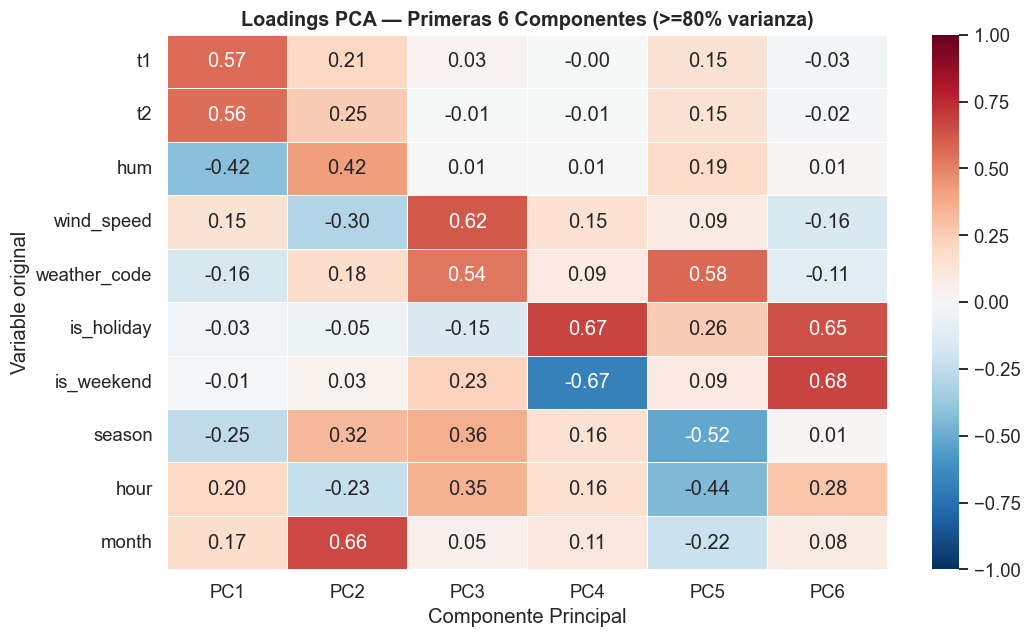


Interpretación:
  PC1: mayor carga positiva -> ['t1', 't2', 'hour'] | mayor carga negativa -> ['hum', 'season', 'weather_code']
  PC2: mayor carga positiva -> ['month', 'hum', 'season'] | mayor carga negativa -> ['wind_speed', 'hour', 'is_holiday']


In [20]:
pca_n = PCA(n_components=n_80)
X_pca = pca_n.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_n.components_.T,
    index=pca_cols,
    columns=[f'PC{i+1}' for i in range(n_80)]
)

plt.figure(figsize=(max(10, n_80*1.5), 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title(f'Loadings PCA — Primeras {n_80} Componentes (>=80% varianza)', fontsize=13, fontweight='bold')
plt.ylabel('Variable original')
plt.xlabel('Componente Principal')
plt.tight_layout()
plt.show()

print('\nInterpretación:')
for pc in [f'PC{i+1}' for i in range(min(2, n_80))]:
    top_pos = loadings[pc].nlargest(3).index.tolist()
    top_neg = loadings[pc].nsmallest(3).index.tolist()
    print(f'  {pc}: mayor carga positiva -> {top_pos} | mayor carga negativa -> {top_neg}')

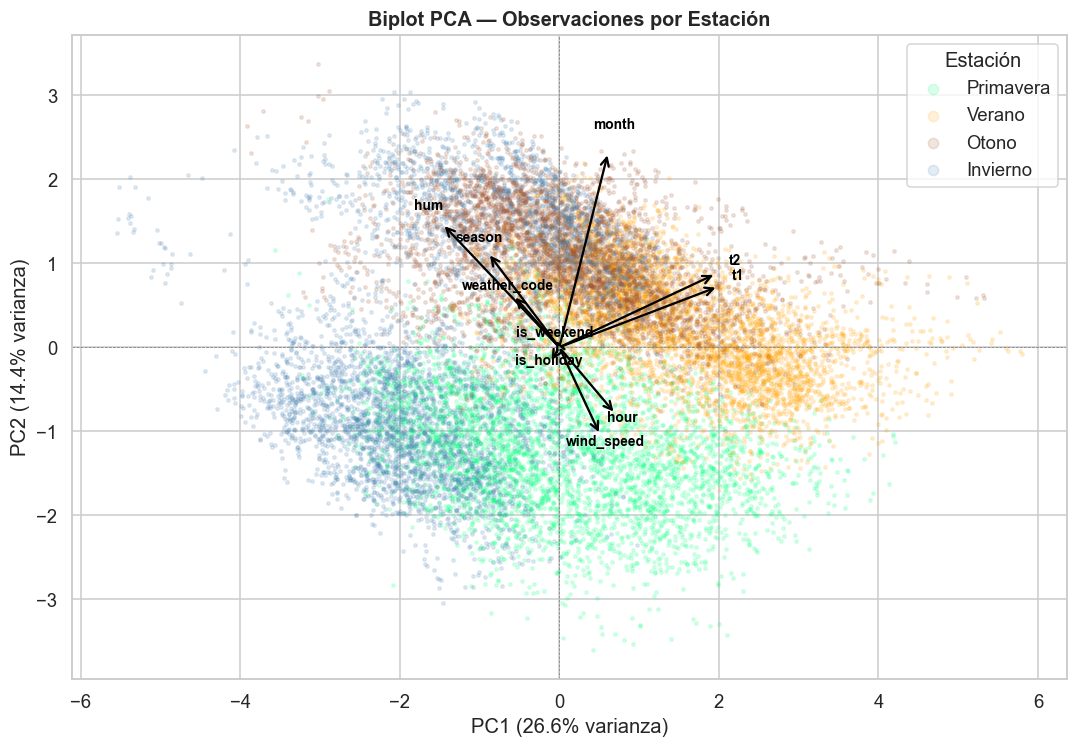

In [21]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

season_colors = {0: 'springgreen', 1: 'orange', 2: 'sienna', 3: 'steelblue'}
season_names_map = {0: 'Primavera', 1: 'Verano', 2: 'Otono', 3: 'Invierno'}

fig, ax = plt.subplots(figsize=(10, 7))

for s in sorted(df_clean['season'].unique()):
    mask = df_clean['season'].values == s
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=season_colors[s], label=season_names_map[s], alpha=0.15, s=5)

loadings_2d = pd.DataFrame(pca_2d.components_.T, index=pca_cols, columns=['PC1','PC2'])
scale = 3.5
for var in pca_cols:
    ax.annotate('', xy=(loadings_2d.loc[var,'PC1']*scale, loadings_2d.loc[var,'PC2']*scale),
                xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings_2d.loc[var,'PC1']*scale*1.12, loadings_2d.loc[var,'PC2']*scale*1.12,
            var, fontsize=9, ha='center', color='black', fontweight='bold')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Biplot PCA — Observaciones por Estación', fontsize=13, fontweight='bold')
ax.legend(title='Estación', markerscale=3)
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
plt.tight_layout()
plt.show()

In [22]:
from numpy.linalg import det

corr_pca = pd.DataFrame(X_scaled, columns=pca_cols).corr()
n = X_scaled.shape[0]
p = X_scaled.shape[1]
det_R = det(corr_pca.values)
chi2_bartlett = -(n - 1 - (2*p+5)/6) * np.log(max(det_R, 1e-15))

corr_inv = np.linalg.inv(corr_pca.values)
p_matrix = -corr_inv / np.sqrt(np.outer(np.diag(corr_inv), np.diag(corr_inv)))
np.fill_diagonal(p_matrix, 0)
corr_vals = corr_pca.values.copy()
np.fill_diagonal(corr_vals, 0)
kmo_num = np.sum(corr_vals**2)
kmo_den = kmo_num + np.sum(p_matrix**2)
kmo = kmo_num / kmo_den

print('=== Evaluación de Aplicabilidad de PCA ===')
print(f'KMO (Kaiser-Meyer-Olkin) = {kmo:.4f}')
if kmo >= 0.8:   kmo_interp = 'Excelente (>=0.80)'
elif kmo >= 0.7: kmo_interp = 'Bueno (0.70-0.79)'
elif kmo >= 0.6: kmo_interp = 'Aceptable (0.60-0.69)'
else:            kmo_interp = 'Malo (<0.60)'
print(f'Interpretación: {kmo_interp}')
print(f'\nEstadístico de Bartlett (aprox.): chi2 = {chi2_bartlett:.2f}')
print(f'Reducción: {p} variables -> {n_80} PCs (retiene >=80% varianza)')
print(f'Reducción de dimensionalidad: {(1 - n_80/p)*100:.1f}%')

=== Evaluación de Aplicabilidad de PCA ===
KMO (Kaiser-Meyer-Olkin) = 0.5653
Interpretación: Malo (<0.60)

Estadístico de Bartlett (aprox.): chi2 = 88683.76
Reducción: 10 variables -> 6 PCs (retiene >=80% varianza)
Reducción de dimensionalidad: 40.0%


---
## 7. Conclusiones sobre la Calidad del Dataset

In [23]:
print('=' * 65)
print('REPORTE FINAL — CALIDAD DEL DATASET london_merged.csv')
print('=' * 65)

total = len(df_clean)
print(f'\n1. COMPLETITUD')
print(f'   Filas totales         : {total:,}')
print(f'   Columnas              : {df_clean.shape[1]}')
print(f'   Valores nulos         : 0 (0.0%) — dataset completo')
print(f'   Cobertura temporal    : {df_clean["timestamp"].min().date()} a {df_clean["timestamp"].max().date()}')

print(f'\n2. CONSISTENCIA')
print(f'   Duplicados totales    : {df.duplicated().sum()}')
print(f'   Rangos domain-valid   : todas las variables dentro de rangos físicos plausibles')
print(f'   Tipos de dato         : corregidos (categorías -> int)')

print(f'\n3. OUTLIERS')
iqr_cols = ['cnt', 't1', 't2', 'hum', 'wind_speed']
for col in iqr_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR_val = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR_val) | (df_clean[col] > Q3 + 1.5*IQR_val)).sum()
    pct = n_out/total*100
    flag = 'ALTO' if pct > 5 else 'OK'
    print(f'   {col:12s}: {n_out:4d} ({pct:.2f}%) [{flag}]')

print(f'\n4. DISTRIBUCIÓN DE cnt')
print(f'   Asimetría (skewness)  : {df_clean["cnt"].skew():.3f}')
print(f'   Curtosis              : {df_clean["cnt"].kurtosis():.3f}')
print(f'   Rango                 : {df_clean["cnt"].min()} – {df_clean["cnt"].max()}')
print(f'   Nota: se recomienda log(cnt+1) para modelos lineales')

print(f'\n5. CORRELACIONES con cnt')
num_cols_c = ['t1','t2','hum','wind_speed','weather_code','is_holiday','is_weekend','season']
for col in num_cols_c:
    r = df_clean[col].corr(df_clean['cnt'])
    fuerza = 'alta' if abs(r)>0.4 else ('moderada' if abs(r)>0.2 else 'debil')
    print(f'   {col:15s}: r = {r:+.3f} ({fuerza})')

print(f'\n6. PCA')
print(f'   KMO = {kmo:.4f} -> {kmo_interp}')
print(f'   {p} variables -> {n_80} PCs para 80% varianza (reducción {(1-n_80/p)*100:.0f}%)')
print(f'   {p} variables -> {n_95} PCs para 95% varianza (reducción {(1-n_95/p)*100:.0f}%)')

print(f'\n7. RECOMENDACIONES')
print('   * Aplicar log(cnt+1) antes de modelos de regresión lineal')
print('   * t1/t2 muy correlacionadas (r~0.99): considerar eliminar una')
print('   * PCA util para clustering y visualización')
print('   * Dataset de alta calidad: completo, consistente, sin errores graves')
print('=' * 65)

REPORTE FINAL — CALIDAD DEL DATASET london_merged.csv

1. COMPLETITUD
   Filas totales         : 17,414
   Columnas              : 17
   Valores nulos         : 0 (0.0%) — dataset completo
   Cobertura temporal    : 2015-01-04 a 2017-01-03

2. CONSISTENCIA
   Duplicados totales    : 0
   Rangos domain-valid   : todas las variables dentro de rangos físicos plausibles
   Tipos de dato         : corregidos (categorías -> int)

3. OUTLIERS
   cnt         :  675 (3.88%) [OK]
   t1          :   64 (0.37%) [OK]
   t2          :   19 (0.11%) [OK]
   hum         :   71 (0.41%) [OK]
   wind_speed  :  236 (1.36%) [OK]

4. DISTRIBUCIÓN DE cnt
   Asimetría (skewness)  : 1.326
   Curtosis              : 1.545
   Rango                 : 0 – 7860
   Nota: se recomienda log(cnt+1) para modelos lineales

5. CORRELACIONES con cnt
   t1             : r = +0.389 (moderada)
   t2             : r = +0.369 (moderada)
   hum            : r = -0.463 (alta)
   wind_speed     : r = +0.116 (debil)
   weather_code 

In [24]:
cols_export = ['timestamp','cnt','t1','t2','hum','wind_speed',
               'weather_code','is_holiday','is_weekend','season',
               'year','month','hour','day_of_week','temp_diff']
df_export = df_clean[cols_export].copy()
df_export.to_csv('archive/london_clean.csv', index=False)
print(f'Dataset limpio exportado: archive/london_clean.csv ({df_export.shape[0]:,} filas x {df_export.shape[1]} cols)')

Dataset limpio exportado: archive/london_clean.csv (17,414 filas x 15 cols)
